# Email Spam Detection and Classification

This notebook demonstrates a complete machine learning pipeline for detecting and classifying spam emails. I amusing the `spambase` dataset, which can be imported directly using `scikit-learn`'s `fetch_openml` function. The dataset contains 57 continuous features representing word and character frequencies extracted from emails, and a binary target label (1 = spam, 0 = non-spam).

In [1]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
sns.set_theme(style="whitegrid")

## 1. Data Loading
I loaded the `spambase` dataset from OpenML.

In [2]:
print("Fetching the spambase dataset...")
spam_data = fetch_openml(name='spambase', version=1, as_frame=True, parser='auto')
X = spam_data.data
y = spam_data.target
df = X.copy()
df['target'] = y
print(f"Dataset shape: {df.shape}")
df.head()

Fetching the spambase dataset...
Dataset shape: (4601, 58)


,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_%3B,char_freq_%28,char_freq_%5B,char_freq_%21,char_freq_%24,char_freq_%23,capital_run_length_average,capital_run_length_longest,capital_run_length_total,target
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


## 2. Exploratory Data Analysis (EDA)
Let's check the distribution of the target variable and look for any missing values.

In [3]:
print("Missing values in dataset:", df.isnull().sum().sum())
print("\nTarget data type:", df['target'].dtype)

Missing values in dataset: 0

Target data type: category


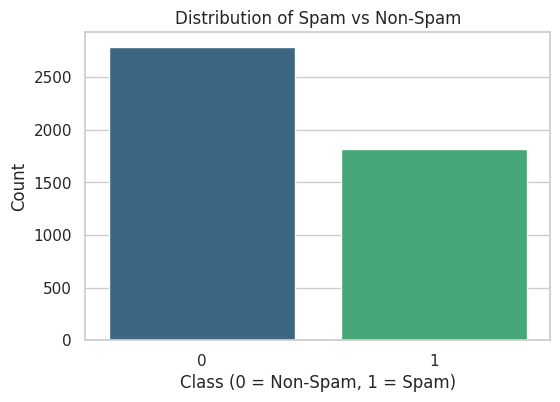

Class distribution:
target
0    60.595523
1    39.404477
Name: proportion, dtype: float64


In [4]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='target', palette='viridis')
plt.title("Distribution of Spam vs Non-Spam")
plt.xlabel("Class (0 = Non-Spam, 1 = Spam)")
plt.ylabel("Count")
plt.show()
print("Class distribution:")
print(df['target'].value_counts(normalize=True) * 100)

## 3. Data Preprocessing
I have to split the data into training and testing sets. Also, since the features have different scales, i have to standardize them.

In [5]:
y = y.astype(int)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Training data shape: (3680, 57)
Testing data shape: (921, 57)


In [6]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 4. Model Training
I will train two different models to compare their performance:
1. **Gaussian Naive Bayes**: A simple and fast probabilistic classifier, often a good baseline for text/frequency data.
2. **Random Forest Classifier**: A powerful ensemble method that usually performs very well on tabular data.

In [7]:
# 1. Initialize and train Gaussian Naive Bayes
nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)

# 2. Initialize and train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)
print("Models trained successfully!")

Models trained successfully!


## 5. Model Evaluation
Let's evaluate both models on the test set using Accuracy, Precision, Recall, and the F1-Score.

In [8]:
# Predictions
nb_preds = nb_model.predict(X_test_scaled)
rf_preds = rf_model.predict(X_test_scaled)

print("--- Gaussian Naive Bayes Performance ---")
print(classification_report(y_test, nb_preds))

print("\n--- Random Forest Performance ---")
print(classification_report(y_test, rf_preds))

--- Gaussian Naive Bayes Performance ---
              precision    recall  f1-score   support

           0       0.97      0.75      0.84       558
           1       0.71      0.96      0.82       363

    accuracy                           0.83       921
   macro avg       0.84      0.85      0.83       921
weighted avg       0.87      0.83      0.83       921


--- Random Forest Performance ---
              precision    recall  f1-score   support

           0       0.94      0.97      0.95       558
           1       0.95      0.91      0.93       363

    accuracy                           0.94       921
   macro avg       0.95      0.94      0.94       921
weighted avg       0.94      0.94      0.94       921



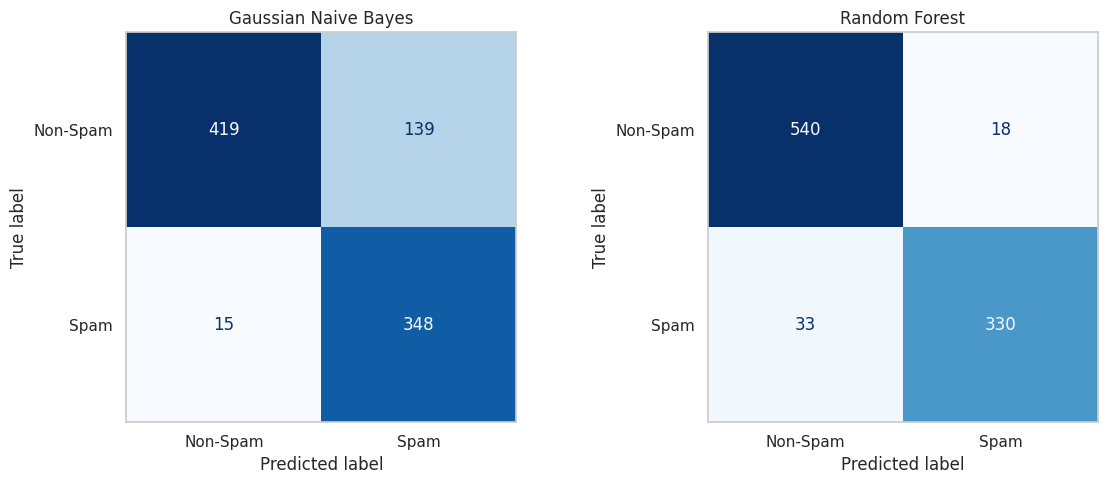

In [9]:
# Plot confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Naive Bayes Confusion Matrix
cm_nb = confusion_matrix(y_test, nb_preds)
disp_nb = ConfusionMatrixDisplay(confusion_matrix=cm_nb, display_labels=["Non-Spam", "Spam"])
disp_nb.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title("Gaussian Naive Bayes")
axes[0].grid(False)

# Random Forest Confusion Matrix
cm_rf = confusion_matrix(y_test, rf_preds)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=["Non-Spam", "Spam"])
disp_rf.plot(ax=axes[1], cmap='Blues', colorbar=False)
axes[1].set_title("Random Forest")
axes[1].grid(False)

plt.tight_layout()
plt.show()

## Conclusion
* **Gaussian Naive Bayes** is fast but might yield a higher number of False Positives (classifying normal emails as spam), as seen in the precision and recall scores.
* **Random Forest** demonstrates excellent performance with high accuracy and a great balance between precision and recall, making it highly effective for this spam detection task.

We can further improve this model by performing hyperparameter tuning using `GridSearchCV` or experimenting with other algorithms like XGBoost or Support Vector Machines.